## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2010-2021.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,37.991999,23.654887,14643.0,NaN,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-12-16,37.950174,23.650108,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,37.991999,23.654887,14292.0,14056.0,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-01-16,37.950174,23.650108,47.880348,2010-01-09,2010-01-02,2010-12-16,2010-12-16,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-01,38.009965,23.825567,14545.0,14253.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-12-16,38.050174,23.850109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-16,38.009965,23.825567,14141.0,14041.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-01-16,38.050174,23.850109,43.371546,2010-01-09,2010-01-02,2010-12-16,2010-12-16,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,2010-01-01,37.933609,23.731244,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,2010-01-01,37.933609,23.731244,14622.0,14349.0,37.933609,23.731244,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,2010-12-16,37.950174,23.750109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0


In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14292.0,14056.0,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,47.880348,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14141.0,14041.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,43.371546,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000


In [11]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0


In [12]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['αθηναιων, δημοτικη κοινοτητα 1ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 2ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 3ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 4ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 5ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 6ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 7ου διαμερισματος δημου αθηναιων', 'ηλιουπολεως', 'ηρακλειου αττικης', 'νικαιας αγιου ιωαννη ρεντη', 'πειραια', 'τροιζηνιας μεθανων']

Length: 12


In [13]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 1ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 2ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 3ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 4ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 5ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 6ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 7ου διαμερισματος δημου αθηναιων',''))

timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('ηλιουπολης','ηλιουπολεως'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('ηρακλειου','ηρακλειου αττικης'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('νικαιας αγιου ι. ρεντη','νικαιας αγιου ιωαννη ρεντη'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('πειραιως','πειραια'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('τροιζηνιας','τροιζηνιας μεθανων'))

In [14]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [15]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [16]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,NaN
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14292.0,14056.0,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,47.880348,47.880348,47.880348,NaN
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,NaN
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14141.0,14041.0,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,43.371546,43.371546,43.371546,NaN
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44635,ωρωπου,αττικης,23.87203,38.23148,2021-12-16,2021,12,0.332711,0.025310,-0.301732,-0.025310,0.393851,0.067054,-0.340066,-0.067054,0.040825,0.036424,0.023316,0.036424,14143.0,13679.0,14162.416667,13829.000000,14433.454545,13928.166667,14402.866667,13848.285714,14782.785714,13972.714286,1008.146841,35.056141,174.637093,NaN
44636,ωρωπου,αττικης,23.89487,38.26741,2021-12-01,2021,12,0.394376,0.264052,-0.218652,-0.264052,0.493563,0.217866,-0.368216,-0.217866,0.043980,0.066067,0.068542,0.066067,14235.0,13883.0,14095.200000,13906.555556,14325.538462,13996.941176,14433.133333,13887.000000,14664.294118,14021.923077,833.509748,68.101352,133.876446,NaN
44637,ωρωπου,αττικης,23.89487,38.26741,2021-12-16,2021,12,0.394376,0.264052,-0.218652,-0.264052,0.140948,0.170854,-0.016425,-0.170854,0.002036,0.041949,0.037374,0.041949,14256.0,13757.0,14095.200000,13906.555556,14325.538462,13996.941176,14433.133333,13887.000000,14664.294118,14021.923077,1008.146841,35.056141,174.637093,NaN
44638,ωρωπου,αττικης,23.66640,38.24944,2021-12-01,2021,12,0.490463,0.344806,-0.288575,-0.344806,0.495182,0.236252,-0.362538,-0.236252,0.050102,0.099596,0.059656,0.099596,14224.0,13985.0,14181.071429,13856.875000,14394.923077,13974.722222,14447.000000,13903.750000,14734.000000,14042.230769,792.204414,72.777108,139.635317,NaN


In [17]:
merged = fillna(merged,{'case': 0})

In [18]:
merged['case'].value_counts()

0.0     44158
1.0       333
2.0        82
3.0        31
6.0        19
4.0        13
5.0         2
9.0         1
11.0        1
Name: case, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [20]:
dataset = grouped.mean()

In [21]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,0.0
1,2010-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2010.0,1.0,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,0.0
2,2010-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2010.0,1.0,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2010.0,1.0,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000,0.0
4,2010-01-01,αγκιστριου,αττικης,23.340090,37.695030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2021.0,12.0,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,1014.150453,49.260338,137.068177,0.0
19004,2021-12-16,φυλης,αττικης,23.688620,38.106703,2021.0,12.0,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,952.604572,38.901573,132.448505,0.0
19005,2021-12-16,χαλανδριου,αττικης,23.809410,38.022260,2021.0,12.0,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,1082.514330,66.593548,167.316474,0.0
19006,2021-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2021.0,12.0,0.167201,0.172458,-0.027057,-0.172458,0.185951,0.163802,-0.068775,-0.163802,0.055264,0.065290,0.044935,0.065290,14162.000000,13843.000000,14279.214286,13995.111111,14488.812500,14070.055556,14509.800000,14037.058824,14910.875000,14194.214286,1002.432535,36.845405,119.446319,0.0


In [22]:
dataset = dataset.astype({'case': 'int'})

In [23]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [24]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [25]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [27]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,0,1,53,44.75555,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,0,1,53,44.85879,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,0,1,53,44.74465,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000,0,1,53,44.83209,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000,0,1,53,44.33593,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2021,12,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,1014.150453,49.260338,137.068177,0,16,50,44.83787,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
19004,2021-12-16,φυλης,αττικης,23.68862,38.10670,2021,12,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,952.604572,38.901573,132.448505,0,16,50,44.86949,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
19005,2021-12-16,χαλανδριου,αττικης,23.80941,38.02226,2021,12,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,1082.514330,66.593548,167.316474,0,16,50,44.86179,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
19006,2021-12-16,χαϊδαριου,αττικης,23.63084,38.00942,2021,12,0.167201,0.172458,-0.027057,-0.172458,0.185951,0.163802,-0.068775,-0.163802,0.055264,0.065290,0.044935,0.065290,14162.000000,13843.000000,14279.214286,13995.111111,

<AxesSubplot:>

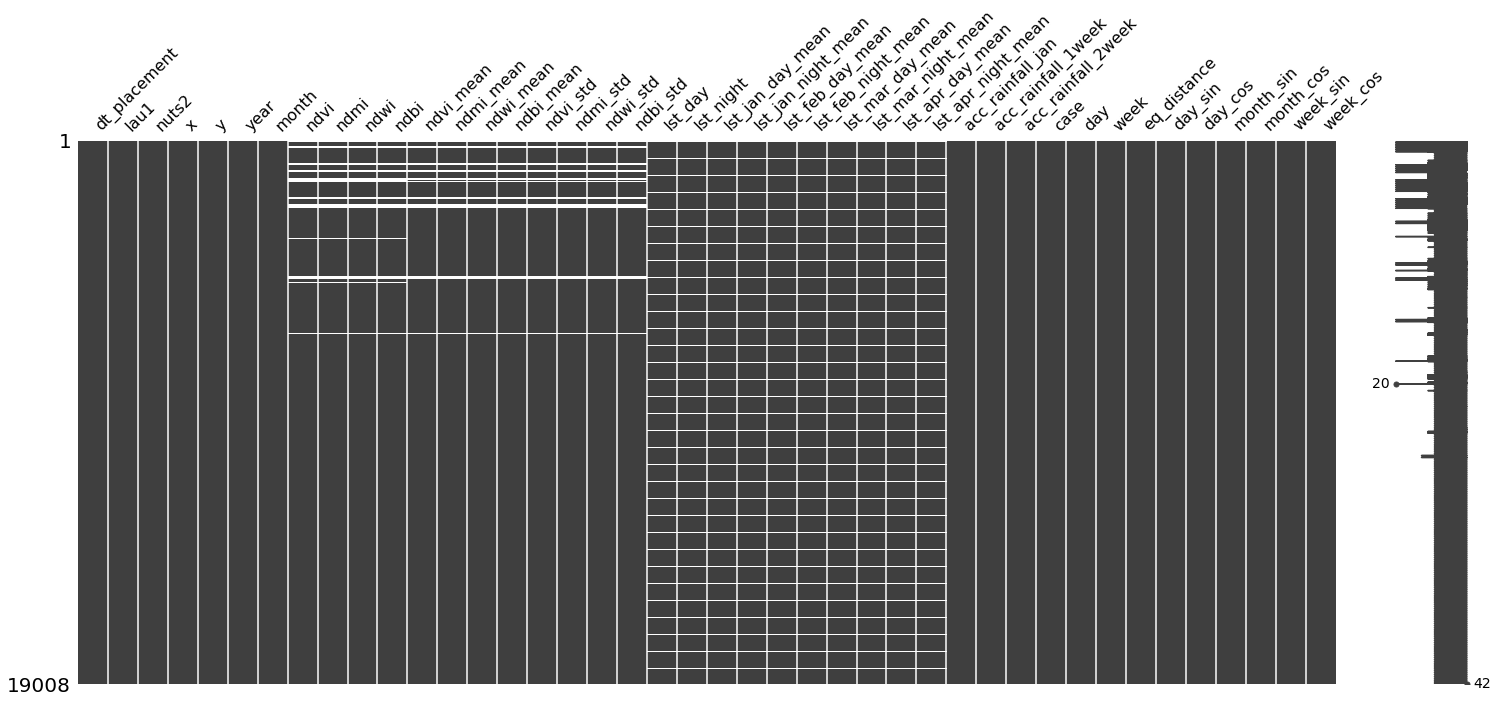

In [28]:
missingno.matrix(dataset)

In [29]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [30]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [31]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [32]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [33]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας βαρβαρας,2.4,10925.9,26759.0
1,αγιας παρασκευης,7.9,7557.5,62157.0
2,αγιου δημητριου,5.0,14402.8,71747.0
3,αγιων αναργυρων καματερου,9.2,6833.8,61427.0
4,αγκιστριου,13.4,85.2,1107.0
...,...,...,...,...
61,φιλοθεης ψυχικου,6.1,4421.0,27400.0
62,φυλης,109.1,421.2,48255.0
63,χαϊδαριου,22.7,2069.6,46983.0
64,χαλανδριου,10.8,6869.6,77118.0


In [34]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ηλιουπολεως', 'ηρακλειου αττικης', 'φιλαδελφειας χαλκηδονος']

Length: 3


In [35]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηλιουπολης','ηλιουπολεως'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρακλειου','ηρακλειου αττικης'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νεας φιλαδελφειας νεας χαλκηδονας','φιλαδελφειας χαλκηδονος'))


In [36]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [37]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

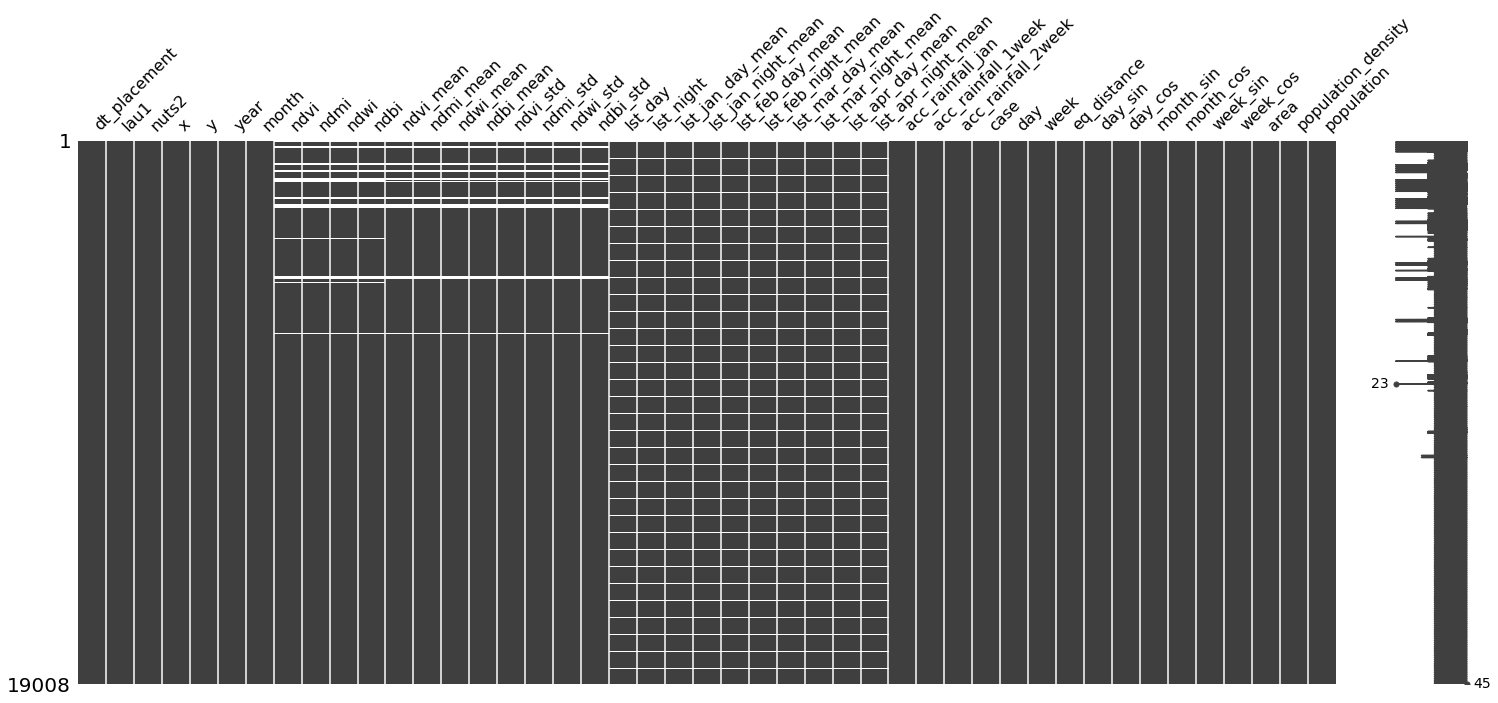

In [38]:
missingno.matrix(dataset)

In [39]:
missing = describe_dataframe(dataset)

In [40]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,0,1,53,44.75555,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,2.4,10925.9,26759.0
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,0,1,53,44.85879,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,7.9,7557.5,62157.0
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,0,1,53,44.74465,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,5.0,14402.8,71747.0
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000,0,1,53,44.83209,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.2,6833.8,61427.0
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000,0,1,53,44.33593,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,13.4,85.2,1107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2021,12,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,1014.150453,49.260338,137.068177,0,16,50,44.83787,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,6.1,4421.0,27400.0
19004,2021-12-16,φυλης,αττικης,23.68862,38.10670,2021,12,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,952.604572,38.901573,132.448505,0,16,50,44.86949,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,109.1,421.2,48255.0
19005,2021-12-16,χαλανδριου,αττικης,23.80941,38.02226,2021,12,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,1082.514330,66.593548,167.316474,0,16,50,44.86179,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,10.8,6869.6,77118.0
19006,2021-12-16,χαϊδαρι

In [41]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2010-01-01,29
1,23.826420,38.008060,2010-01-01,27
2,23.730310,37.933570,2010-01-01,38
3,23.713410,38.047210,2010-01-01,35
4,23.340090,37.695030,2010-01-01,38
...,...,...,...,...
19003,23.776280,38.014770,2021-12-16,1
19004,23.688620,38.106703,2021-12-16,1
19005,23.809410,38.022260,2021-12-16,1
19006,23.630840,38.009420,2021-12-16,1


In [42]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [43]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [44]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0


In [45]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [46]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [47]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [48]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.60,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.0,0.0,0.0,0,1,53,44.75555,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,10925.9,26759.0,55
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.00,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.0,0.0,0.0,0,1,53,44.85879,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,7557.5,62157.0,4
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.75,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.0,0.0,0.0,0,1,53,44.74465,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,14402.8,71747.0,1
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.0,14269.0,14258.00,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.0,0.0,0.0,0,1,53,44.83209,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,6833.8,61427.0,35
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.0,14463.0,14338.25,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.0,0.0,0.0,0,1,53,44.33593,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,85.2,1107.0,41


<AxesSubplot:>

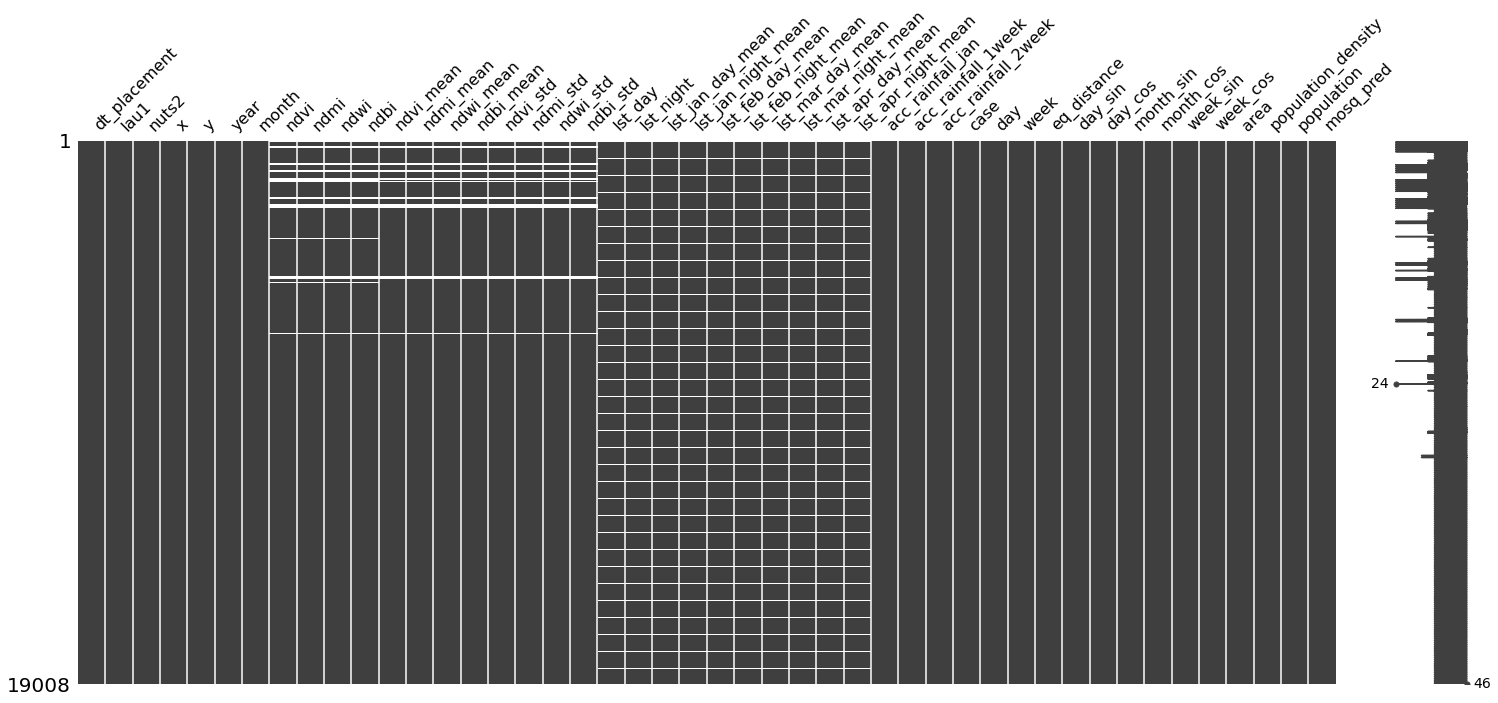

In [49]:
missingno.matrix(dataset)

In [50]:
dataset.reset_index(inplace=True, drop=True)

In [51]:
dataset = calculate_mosq_previous(dataset)

In [52]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

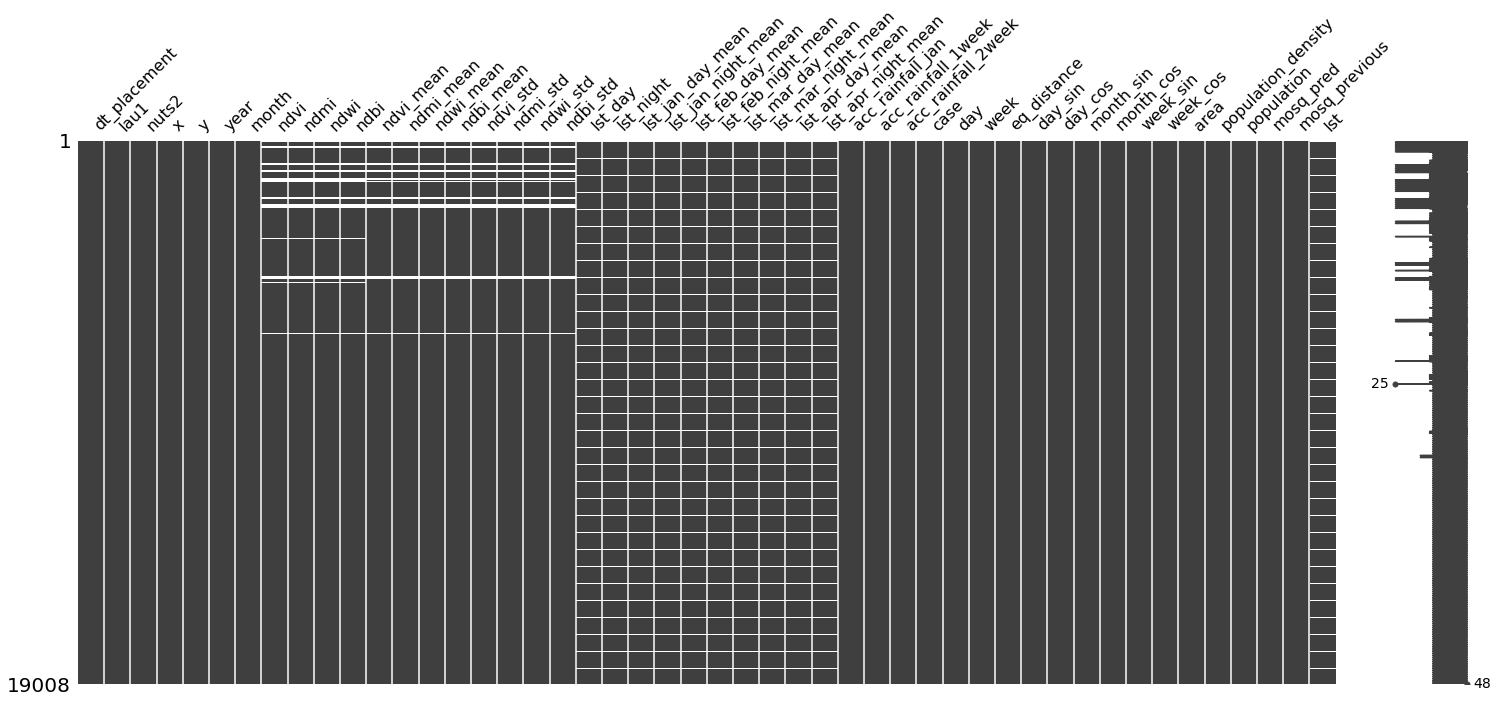

In [53]:
missingno.matrix(dataset)

In [54]:
dataset['case'].value_counts()

0     18836
1       122
2        27
3        11
4         5
6         3
5         2
11        1
9         1
Name: case, dtype: int64

In [55]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [56]:
dataset = convert_multiple_cases(dataset)

In [57]:
dataset['case'].value_counts()

0    18836
1      277
Name: case, dtype: int64

In [58]:
cols = dataset.columns

In [59]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [60]:
len(cols)

48

In [61]:
# check columns

In [62]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [63]:
len(final_columns)

48

In [64]:
dataset_final = dataset[final_columns].copy()

In [65]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.0,0.000000,0.000000,55,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.0,0.000000,0.000000,4,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.0,0.000000,0.000000,1,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.0,0.000000,0.000000,35,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,0.0,0.000000,0.000000,41,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19108,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,12.101125,592.518341,26,52,1
19109,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,12.101125,592.518341,26,52,1
19110,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,12.101125,592.518341,26,52,1
19111,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964

In [66]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)